In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra|
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
df = pd.read_csv(r"C:\Users\KIIT\Downloads\Folder\Customer-Churn-End-to-End\WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
#  Understand the relevance of traget, as this is the main thing we are trying to predict
# Check for imbalance, an often useful trick to see and check for distribution of target in the dataset

df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
df["Churn"].value_counts(normalize=True)

# This cell concludes that no. of churners are less and class ratio is 1:4 i.e.
# 4 people would use that service, 1 for some reason likely(beheviour in x set of features) 
# would churn or leave that service, we do this as
# this is important for modelling later and assigining class weights
 

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [6]:
''' 
Most of the times, that's why it is recommended to look at dataset TotalCharges
feature was actually numeric, but has been labelled as object, and has 11 missing
values, and for missing values, in dataset if we have "" like this, so it got labelled as object
'''
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [9]:
import warnings
warnings.filterwarnings('ignore')

df["TotalCharges"].fillna(0, inplace=True)

In [10]:
%pip install scikit-learn --upgrade
%pip install xgboost --upgrade
%pip install matplotlib --upgrade
%pip install seaborn --upgrade

Note: you may need to restart the kernel to use updated packages.
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 1.4 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.3 MB 2.6 MB/s eta 0:00:03
   ------------- -------------------------- 2.9/8.3 MB 4.2 MB/s eta 0:00:02
   ------------- -------------------------- 2.9/8.3 MB 4.2 MB/s eta 0:00:02
   ------------- -------------------------- 2.9/8.3 MB 4.2 MB/s eta 0:00:02
   ------------- -------------------------- 2.9/8.3 MB 4.2 MB/s eta 0:00:02
   ----------

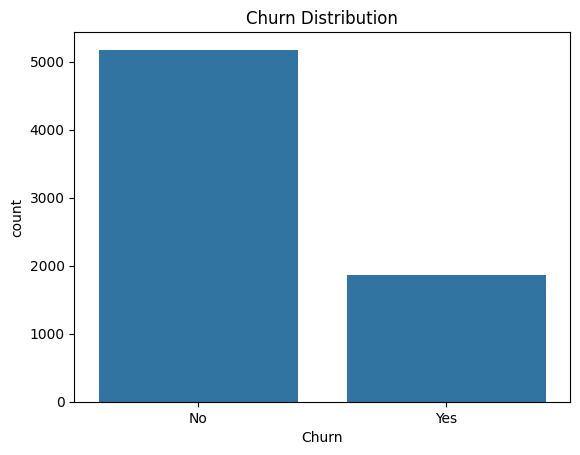

In [11]:
# Plotting imbalance here, to have a visual look at how our target is distributed

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

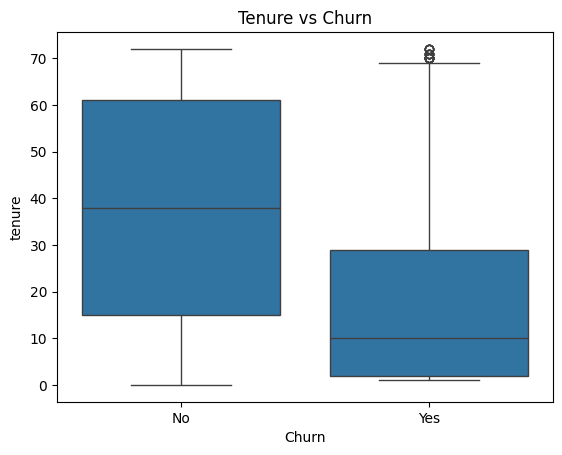

In [12]:
# We now do a hypothesis assumption of univariate analysis to see how one feature impacts the other and we understand how much of a predictor it will be to a model

sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

In [13]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [14]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


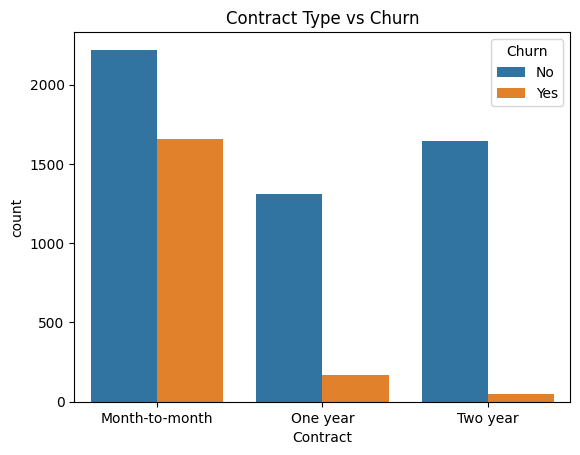

In [15]:
# Now we do this with contract

sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.show()

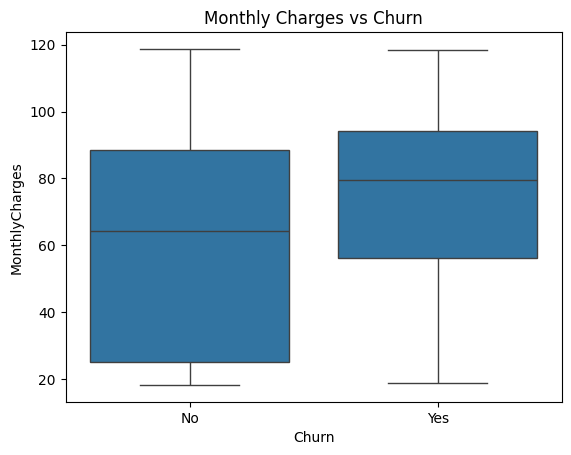

In [16]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [17]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


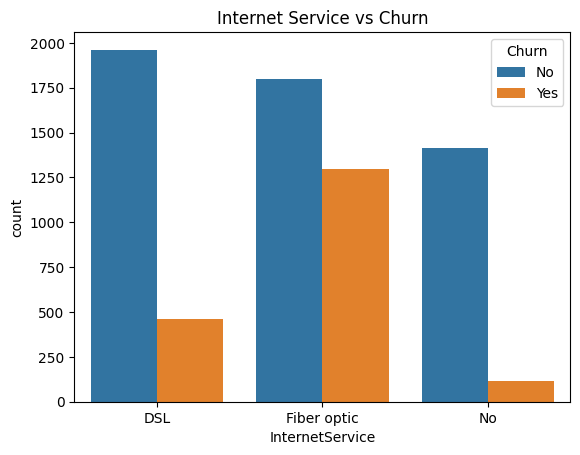

In [18]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Internet Service vs Churn")
plt.show()

In [19]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index")

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


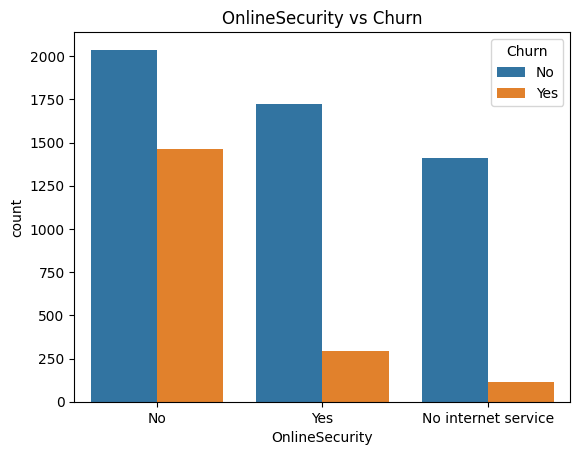

In [20]:
sns.countplot(x="OnlineSecurity", hue="Churn", data=df)
plt.title("OnlineSecurity vs Churn")
plt.show()

In [21]:
pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index")

Churn,No,Yes
OnlineSecurity,,
No,0.582333,0.417667
No internet service,0.925950,0.074050
Yes,0.853888,0.146112


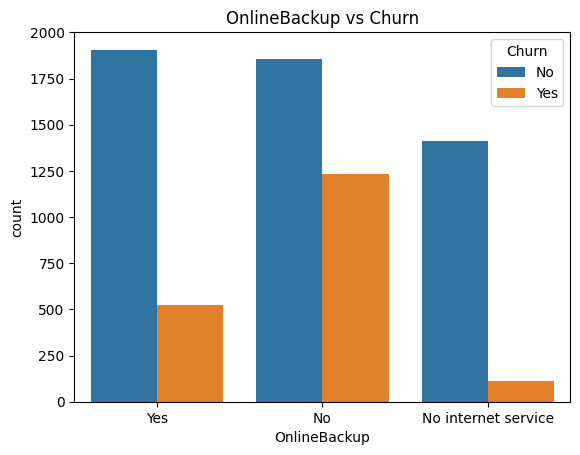

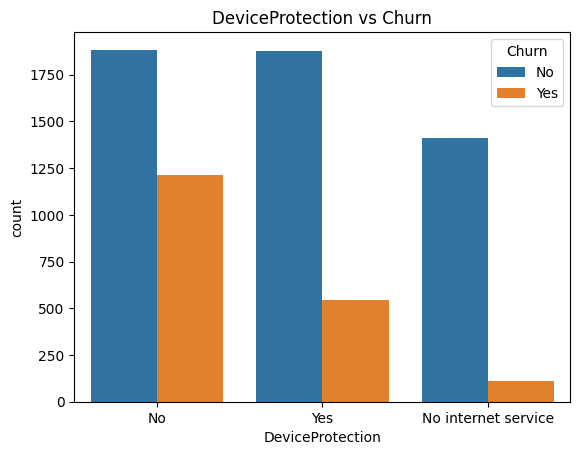

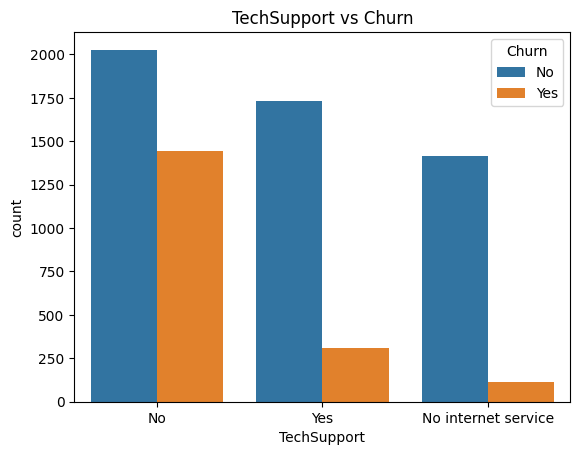

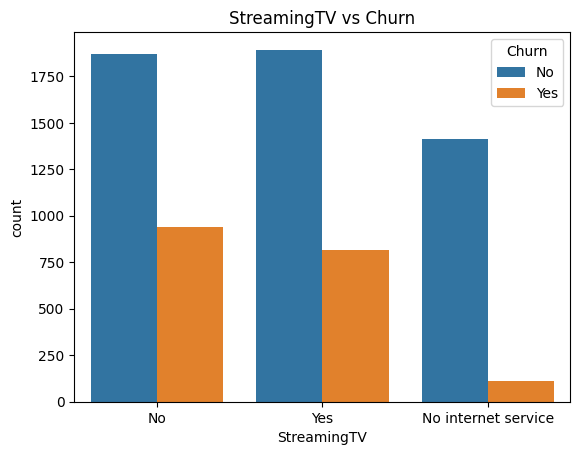

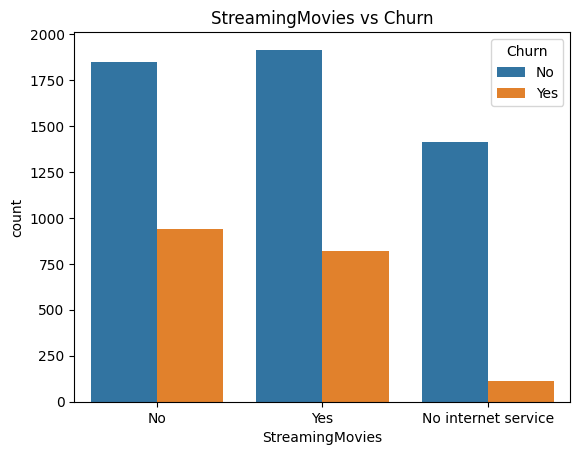

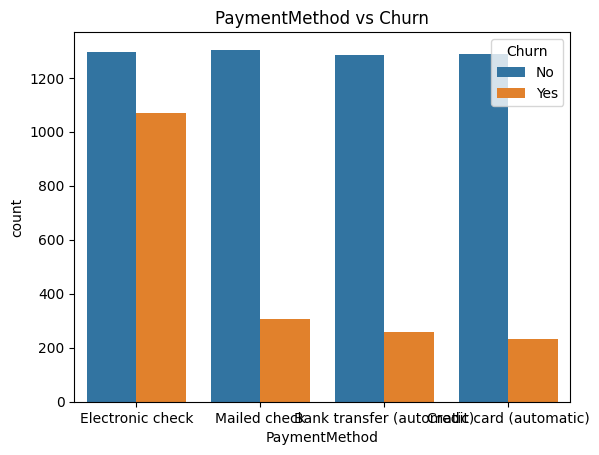

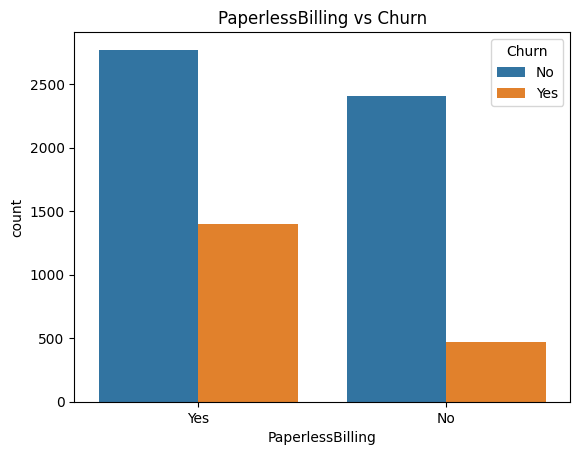

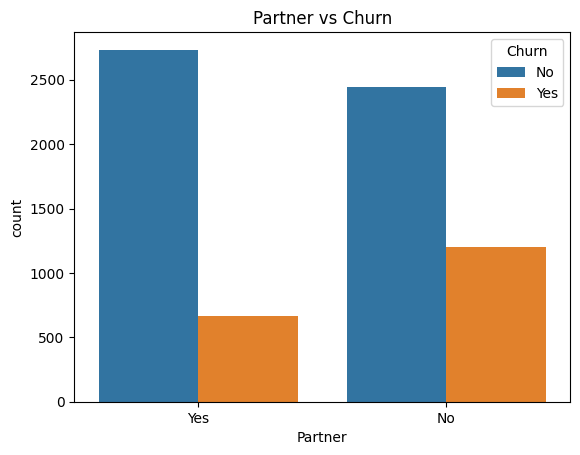

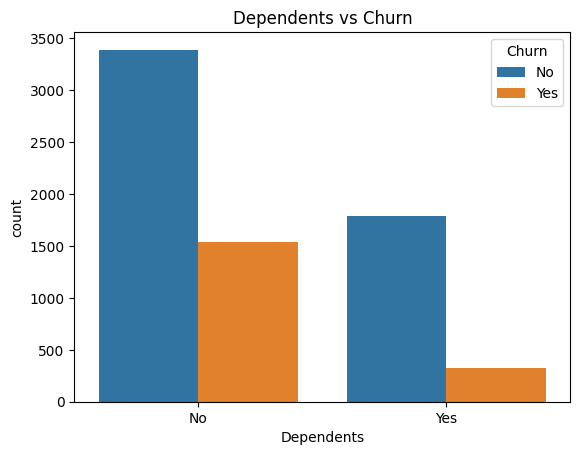

In [22]:
categorical_cols = [
'OnlineBackup',
'DeviceProtection',
'TechSupport',
'StreamingTV',
'StreamingMovies',
'PaymentMethod',
'PaperlessBilling',
'Partner',
'Dependents'
]

for col in categorical_cols:
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

In [23]:
categorical_cols = [
'Partner','Dependents','PhoneService','MultipleLines',
'OnlineBackup','DeviceProtection','TechSupport',
'StreamingTV','StreamingMovies','PaymentMethod','PaperlessBilling'
]

for col in categorical_cols:
    print(f"\n===== {col} vs Churn =====")
    ct = pd.crosstab(df[col], df["Churn"], normalize="index") * 100
    print(ct.round(2))


===== Partner vs Churn =====
Churn       No    Yes
Partner              
No       67.04  32.96
Yes      80.34  19.66

===== Dependents vs Churn =====
Churn          No    Yes
Dependents              
No          68.72  31.28
Yes         84.55  15.45

===== PhoneService vs Churn =====
Churn            No    Yes
PhoneService              
No            75.07  24.93
Yes           73.29  26.71

===== MultipleLines vs Churn =====
Churn                No    Yes
MultipleLines                 
No                74.96  25.04
No phone service  75.07  24.93
Yes               71.39  28.61

===== OnlineBackup vs Churn =====
Churn                   No    Yes
OnlineBackup                     
No                   60.07  39.93
No internet service  92.60   7.40
Yes                  78.47  21.53

===== DeviceProtection vs Churn =====
Churn                   No    Yes
DeviceProtection                 
No                   60.87  39.13
No internet service  92.60   7.40
Yes                  77.50  22.50



In [24]:
from scipy.stats import chi2_contingency

categorical_cols = [
'Partner','Dependents','PhoneService','MultipleLines',
'InternetService','OnlineSecurity','OnlineBackup',
'DeviceProtection','TechSupport','StreamingTV',
'StreamingMovies','Contract','PaymentMethod',
'PaperlessBilling'
]

for col in categorical_cols:
    table = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, expected = chi2_contingency(table)

    print(f"\nFeature: {col}")
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"P-value: {p:.6f}")


Feature: Partner
Chi-square statistic: 158.7334
P-value: 0.000000

Feature: Dependents
Chi-square statistic: 189.1292
P-value: 0.000000

Feature: PhoneService
Chi-square statistic: 0.9150
P-value: 0.338783

Feature: MultipleLines
Chi-square statistic: 11.3304
P-value: 0.003464

Feature: InternetService
Chi-square statistic: 732.3096
P-value: 0.000000

Feature: OnlineSecurity
Chi-square statistic: 849.9990
P-value: 0.000000

Feature: OnlineBackup
Chi-square statistic: 601.8128
P-value: 0.000000

Feature: DeviceProtection
Chi-square statistic: 558.4194
P-value: 0.000000

Feature: TechSupport
Chi-square statistic: 828.1971
P-value: 0.000000

Feature: StreamingTV
Chi-square statistic: 374.2039
P-value: 0.000000

Feature: StreamingMovies
Chi-square statistic: 375.6615
P-value: 0.000000

Feature: Contract
Chi-square statistic: 1184.5966
P-value: 0.000000

Feature: PaymentMethod
Chi-square statistic: 648.1423
P-value: 0.000000

Feature: PaperlessBilling
Chi-square statistic: 258.2776
P-value

In [25]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [26]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [27]:
df["tenure_bucket"] = pd.cut(
    df["tenure"],
    bins=[0,12,36,60,72],
    labels=["0-12","12-36","36-60","60+"]
)

In [29]:
df["tenure_bucket"] = pd.cut(
    df["tenure"],
    bins=[0,12,36,60,72],
    labels=["0-12","12-36","36-60","60+"]
)

In [28]:
services = [
"OnlineSecurity",
"OnlineBackup",
"DeviceProtection",
"TechSupport",
"StreamingTV",
"StreamingMovies"
]

df["service_count"] = df[services].apply(lambda x: (x == "Yes").sum(), axis=1)

In [29]:
df["charges_per_tenure"] = df["TotalCharges"] / (df["tenure"] + 1)

In [30]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bucket,service_count,charges_per_tenure
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12,1,14.925000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,12-36,2,53.985714
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12,2,36.050000
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,36-60,3,40.016304
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12,0,50.550000


In [31]:
df[["tenure_bucket","service_count","charges_per_tenure"]].describe()

,service_count,charges_per_tenure
count,7043.000000,7043.000000
mean,2.037910,58.990789
std,1.847682,30.579745
min,0.000000,0.000000
25%,0.000000,26.041493
50%,2.000000,60.937879
75%,3.000000,84.830742
max,6.000000,118.969863


In [32]:
df["Churn"] = df["Churn"].map({"No":0, "Yes":1})

In [33]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['customerID', 'Churn'], axis = 1)
y = df['Churn']

X_train, X_rem, y_train, y_rem = train_test_split(X, y, stratify = y, random_state = 42, test_size = 0.2)

X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, stratify = y_rem, random_state = 42, test_size = 0.5)

print(f"Train shape: {X_train.shape}")
print(f"Val shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (5634, 22)
Val shape: (704, 22)
Test shape: (705, 22)


In [34]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges",
                    "service_count", "charges_per_tenure"]

categorical_features = [col for col in X.columns if col not in numeric_features]

In [35]:
print(f"X shape: {X.shape}")
print(f"Y shape: {y.shape}")

X shape: (7043, 22)
Y shape: (7043,)


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, penalty = "l2", C= 0.1, class_weight = "balanced"))
])


log_model.fit(X_train, y_train)

y_val_pred = log_model.predict(X_val)
y_val_prob = log_model.predict_proba(X_val)[:,1]

print("Validation Results\n")
print(classification_report(y_val, y_val_pred))

print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

Validation Results

              precision    recall  f1-score   support

           0       0.90      0.70      0.79       517
           1       0.49      0.79      0.61       187

    accuracy                           0.73       704
   macro avg       0.70      0.75      0.70       704
weighted avg       0.79      0.73      0.74       704

ROC-AUC: 0.8505880284239598


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

y_val_pred = rf_model.predict(X_val)
y_val_prob = rf_model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83       517
           1       0.55      0.73      0.63       187

    accuracy                           0.77       704
   macro avg       0.72      0.76      0.73       704
weighted avg       0.80      0.77      0.78       704

ROC-AUC: 0.8439785268776052


In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

param_grid = {
    "classifier__n_estimators":[200,400,600],
    "classifier__max_depth":[6,10,14],
    "classifier__min_samples_split":[2,5],
    "classifier__min_samples_leaf":[1,3]
}

grid = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'classifier__max_depth': 6, 'classifier__min_samples_leaf': 3, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 400}


In [39]:
best_rf = grid.best_estimator_

y_val_pred = best_rf.predict(X_val)
y_val_prob = best_rf.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

              precision    recall  f1-score   support

           0       0.91      0.71      0.79       517
           1       0.50      0.80      0.61       187

    accuracy                           0.73       704
   macro avg       0.70      0.75      0.70       704
weighted avg       0.80      0.73      0.74       704

ROC-AUC: 0.848095243020718


In [40]:
from sklearn.metrics import precision_recall_curve

probs = best_rf.predict_proba(X_val)[:,1]

precision, recall, thresholds = precision_recall_curve(y_val, probs)
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"Thresholds: {thresholds}")

Precision: [0.265625   0.26600284 0.26638177 0.26676177 0.26714286 0.26752504
 0.26790831 0.26829268 0.26867816 0.26906475 0.26945245 0.26984127
 0.27023121 0.27062229 0.27101449 0.27140784 0.27180233 0.27219796
 0.27259475 0.2729927  0.27339181 0.27379209 0.27419355 0.27459618
 0.275      0.27540501 0.27581121 0.27621861 0.27662722 0.27703704
 0.27744807 0.27786033 0.27827381 0.27868852 0.27910448 0.27952167
 0.27994012 0.28035982 0.28078078 0.28120301 0.28162651 0.28205128
 0.28247734 0.28290469 0.28333333 0.28376328 0.28419453 0.28462709
 0.28506098 0.28549618 0.28593272 0.2863706  0.28680982 0.28725038
 0.28769231 0.28813559 0.28858025 0.28902628 0.28947368 0.28992248
 0.29037267 0.29082426 0.29127726 0.29173167 0.2921875  0.29264476
 0.29310345 0.29356358 0.29402516 0.29448819 0.29495268 0.29541864
 0.29588608 0.29635499 0.2968254  0.2972973  0.2977707  0.29824561
 0.29872204 0.2992     0.29967949 0.30016051 0.30064309 0.30112721
 0.3016129  0.30210016 0.302589   0.30307942 0.3035

In [41]:
from sklearn.inspection import permutation_importance
import pandas as pd

perm = permutation_importance(
    best_rf,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42,
    scoring="recall",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance": perm.importances_mean
})

importance_df = importance_df.sort_values(by="importance", ascending=False)

print(importance_df.head(15))

               feature  importance
14            Contract    0.195187
7      InternetService    0.048128
4               tenure    0.024064
21  charges_per_tenure    0.018182
18        TotalCharges    0.016043
19       tenure_bucket    0.015508
16       PaymentMethod    0.009626
11         TechSupport    0.007487
15    PaperlessBilling    0.004813
17      MonthlyCharges    0.003209
6        MultipleLines    0.003209
2              Partner    0.002674
1        SeniorCitizen    0.002674
13     StreamingMovies    0.001070
12         StreamingTV    0.001070


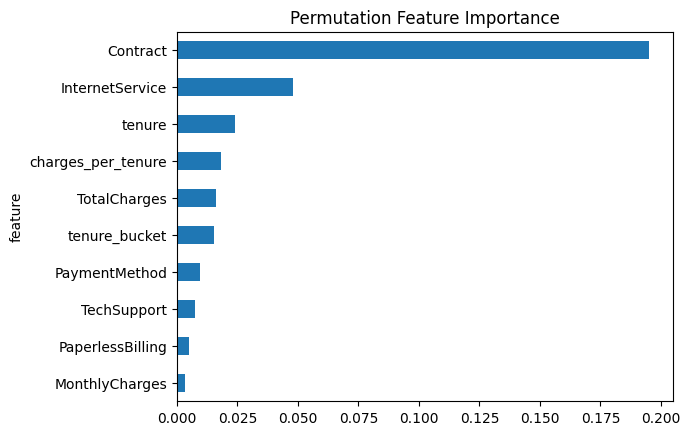

In [42]:
import matplotlib.pyplot as plt

importance_df.head(10).plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False
)

plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance")
plt.show()

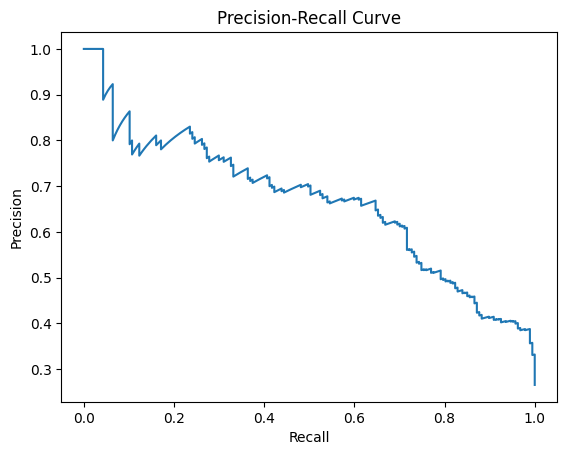

In [43]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Get churn probabilities
y_prob = best_rf.predict_proba(X_val)[:,1]

precision, recall, thresholds = precision_recall_curve(y_val, y_prob)

# Plot PR curve
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [44]:
pr_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

print(pr_df.head(10))

   threshold  precision  recall
0   0.017311   0.265625     1.0
1   0.018477   0.266003     1.0
2   0.018547   0.266382     1.0
3   0.018617   0.266762     1.0
4   0.018699   0.267143     1.0
5   0.020790   0.267525     1.0
6   0.020909   0.267908     1.0
7   0.021446   0.268293     1.0
8   0.021667   0.268678     1.0
9   0.021839   0.269065     1.0


In [45]:
threshold = 0.40

y_pred_custom = (y_prob >= threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_val, y_pred_custom))

              precision    recall  f1-score   support

           0       0.93      0.63      0.75       517
           1       0.46      0.86      0.60       187

    accuracy                           0.69       704
   macro avg       0.69      0.75      0.67       704
weighted avg       0.80      0.69      0.71       704



In [46]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [47]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

xgb_model.fit(X_train, y_train)

y_val_prob = xgb_model.predict_proba(X_val)[:,1]
y_val_pred = (y_val_prob >= 0.4).astype(int)

print(classification_report(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85       517
           1       0.58      0.69      0.63       187

    accuracy                           0.78       704
   macro avg       0.73      0.75      0.74       704
weighted avg       0.80      0.78      0.79       704

ROC-AUC: 0.840730665397863


In [48]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=600,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=2.7,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

xgb_model.fit(X_train, y_train)

y_prob = xgb_model.predict_proba(X_val)[:,1]
y_pred = (y_prob >= 0.4).astype(int)

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

              precision    recall  f1-score   support

           0       0.91      0.67      0.77       517
           1       0.47      0.82      0.60       187

    accuracy                           0.71       704
   macro avg       0.69      0.74      0.68       704
weighted avg       0.79      0.71      0.72       704

ROC-AUC: 0.846936770136224


In [49]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=2.7
)

xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb)
])

param_grid = {
    "classifier__n_estimators": [300, 500, 700],
    "classifier__max_depth": [3, 4, 5],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
    "classifier__min_child_weight": [1, 3],
    "classifier__gamma": [0, 0.1]
}

grid_xgb = GridSearchCV(
    xgb_pipe,
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print("Best params:", grid_xgb.best_params_)


best_xgb = grid_xgb.best_estimator_

y_prob = best_xgb.predict_proba(X_val)[:,1]
y_pred = (y_prob >= 0.4).astype(int)

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best params: {'classifier__colsample_bytree': 0.8, 'classifier__gamma': 0, 'classifier__learning_rate': 0.03, 'classifier__max_depth': 3, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8}
              precision    recall  f1-score   support

           0       0.92      0.64      0.76       517
           1       0.46      0.84      0.60       187

    accuracy                           0.70       704
   macro avg       0.69      0.74      0.68       704
weighted avg       0.80      0.70      0.71       704

ROC-AUC: 0.8507742115661105


In [50]:
from sklearn.metrics import classification_report, roc_auc_score

# RF predictions
rf_test_prob = best_rf.predict_proba(X_test)[:,1]
rf_test_pred = (rf_test_prob >= 0.4).astype(int)

print("Random Forest Test Results")
print(classification_report(y_test, rf_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_test_prob))

Random Forest Test Results
              precision    recall  f1-score   support

           0       0.93      0.66      0.77       518
           1       0.48      0.87      0.62       187

    accuracy                           0.72       705
   macro avg       0.71      0.76      0.70       705
weighted avg       0.81      0.72      0.73       705

ROC-AUC: 0.8383436912848676


In [51]:
# XGB predictions
xgb_test_prob = best_xgb.predict_proba(X_test)[:,1]
xgb_test_pred = (xgb_test_prob >= 0.4).astype(int)

print("XGBoost Test Results")
print(classification_report(y_test, xgb_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_test_prob))

XGBoost Test Results
              precision    recall  f1-score   support

           0       0.92      0.70      0.80       518
           1       0.50      0.83      0.63       187

    accuracy                           0.74       705
   macro avg       0.71      0.77      0.71       705
weighted avg       0.81      0.74      0.75       705

ROC-AUC: 0.8428808869985339


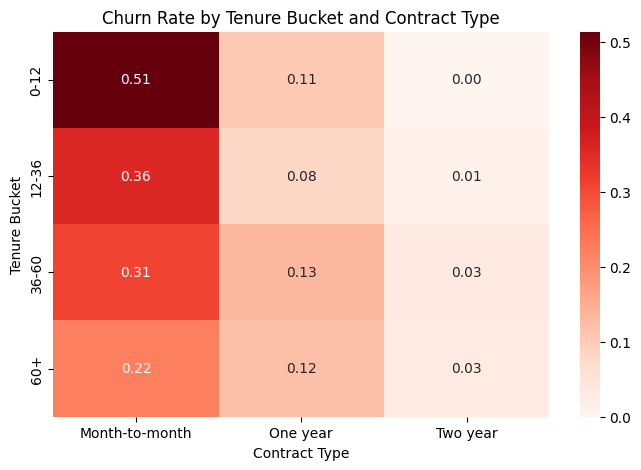

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = pd.crosstab(
    df['tenure_bucket'],
    df['Contract'],
    values=(df['Churn'] == 1).astype(int),
    aggfunc='mean'
)

plt.figure(figsize=(8,5))
sns.heatmap(heatmap_df, annot=True, cmap="Reds", fmt=".2f")

plt.title("Churn Rate by Tenure Bucket and Contract Type")
plt.ylabel("Tenure Bucket")
plt.xlabel("Contract Type")

plt.show()

In [53]:
%pip install shap

  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 559.2/559.2 kB 4.3 MB/s  0:00:00
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.2 MB ? eta -:--:--
    --------------------------------------- 0.5/39.2 MB 802.5 kB/s eta 0:00:49
    --------------------------------------- 0.5/39.2 MB 802.5 kB/s eta 0:00:49
    --------------------------------------- 0.5/39.2 MB 802.5 kB/s eta 0:00:49
    --------------------------------------- 0.5/39.2 MB 802.5 kB/s eta 0:00:49
    --------------------------------------- 0.5/39.2 MB 802.5 kB/s eta 0:00:49
    --------------------------------------- 0.5/39.2 MB 802.5 kB/s eta 0:00:49
    --------------------------------------- 

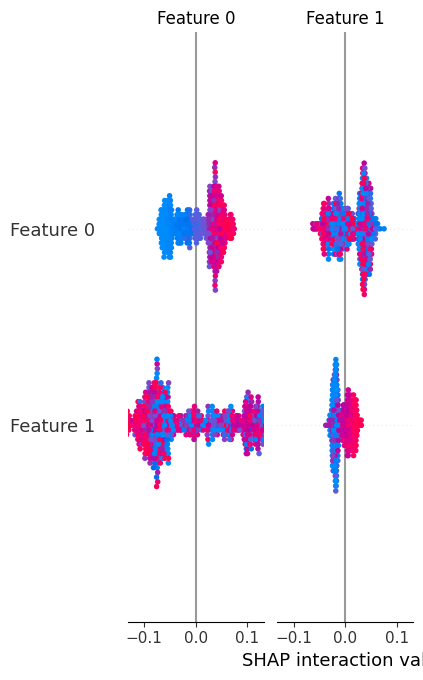

In [54]:
import shap

# extract trained RF model
rf_clf = best_rf.named_steps["classifier"]

# transform validation data
X_val_transformed = best_rf.named_steps["preprocessor"].transform(X_val)

explainer = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_val_transformed)

shap.summary_plot(shap_values, X_val_transformed)

In [55]:
import joblib

joblib.dump(best_rf, "churn_model.pkl")

['churn_model.pkl']